In [1]:
   # Setup check: load the libraries this assignment uses
   import networkx as nx
   import numpy as np
   import matplotlib.pyplot as plt
   import scipy
   import pandas as pd
   import os
   import pickle
   import json
   import warnings
   import pandas as pd 

   print("networkx", nx.__version__, "| numpy", np.__version__, "| scipy", scipy.__version__)

networkx 3.5 | numpy 2.3.3 | scipy 1.16.2


   # NETS/PHYS 7052 — Assignment 01
   Jacopo Conti, Fall 2026

## Question 1 — Network file formats

In [2]:
# Load the directed polblogs graph as in Class 2
data_dir = '../notebooks/class_02_networkx1/data/'

In [3]:
G = nx.DiGraph()
with open(data_dir + 'polblogs_nodes_class.tsv', 'r') as fp:
    for line in fp:
        node_id, node_label, node_political = line.strip().split('\t')
        political_orientation = 'liberal' if node_political == '0' else 'conservative'
        G.add_node(node_id, website=node_label, political_orientation=political_orientation)

with open(data_dir + 'polblogs_edges_class.tsv', 'r') as fp:
    for line in fp:
        source_node_id, target_node_id = line.strip().split('\t')
        G.add_edge(source_node_id, target_node_id)

print("Number of nodes: %d" % G.number_of_nodes())
print("Number of edges: %d" % G.number_of_edges())

Number of nodes: 1490
Number of edges: 19025


### 01.a

In [ ]:
# Create a function to dave results in a dictionary for each format
results = [] # saving results for each format in a list of dictionaries
def table(format_name, filename, G_original, G_loaded):     #These are the parameters of the function ()
    """ The table function takes the parameters as imput and returns a dictionary with the results """
    first_node = list(G_loaded.nodes(data=True))[0] # Get the first node [0] and its attributes from the loaded graph
    return {
        "format": format_name,
        "file_size_bytes": os.path.getsize(filename) if filename else None,
        "nodes": G_loaded.number_of_nodes(),
        "edges": G_loaded.number_of_edges(),
        "directed": G_loaded.is_directed(),
        "attributes_kept": len(first_node[1]) > 0,
        "label_type": type(list(G_loaded.nodes())[0]),
        "graphs_equal": nx.utils.graphs_equal(G_original, G_loaded),
    }

In [ ]:
nx.write_edgelist(G, "polblogs.edgelist") # save G to an edgelist file
G_back = nx.read_edgelist("polblogs.edgelist") # load the graph from the saved edgelist and call it G_back
results.append(table("Edge List", "polblogs.edgelist", G, G_back))  # save the results in the list of dictionaries

In [ ]:
# Print (check) what survived the edge list round trip
print("File size (bytes):", os.path.getsize("polblogs.edgelist"))
print("Nodes:", G_back.number_of_nodes())  # function from class 02
print("Edges:", G_back.number_of_edges()) # function from class 02
print("Directed:", G_back.is_directed())  # function that returns True/False
print("First two nodes:", list(G_back.nodes(data=True))[:2])  # data = True returns a list of tuples)
print("Node label type:", type(list(G_back.nodes())[0]))
print("graphs_equal:", nx.utils.graphs_equal(G, G_back))  # confront G (old) with G_back (new)

# These will be the results that will populate the table at the end

File size (bytes): 218705
Nodes: 1224
Edges: 16718
Directed: False
First two nodes: [('0', {}), ('22', {})]
Node label type: <class 'str'>
graphs_equal: False


In [ ]:
results.append(table("original G", None, G, G))  # append the result to the table to make a confrontation

In [ ]:
nx.write_graphml(G, "polblogs.graphml") # now same with graphml
G_back = nx.read_graphml("polblogs.graphml")
results.append(table("GraphML", "polblogs.graphml", G, G_back))

In [15]:
nx.node_link_data(G)     # Convert the graph to node-link format
with open("polblogs.json", "w") as f: # w for write
    json.dump(nx.node_link_data(G), f) # save the graph in node-link format to a JSON file
with open("polblogs.json", "r") as f: # r for read
    data = json.load(f)
# dictionary → G_back  (nx.node_link_graph)
G_back = nx.node_link_graph(data)
results.append(table("JSON", "polblogs.json", G, G_back))

/Users/jac/anaconda3/envs/cnet5051/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
/Users/jac/anaconda3/envs/cnet5051/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:290: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [10]:
pickle.dump(G, open("polblogs.pickle", "wb"))  # save G to a pickle file; wb = write binary
G_back = pickle.load(open("polblogs.pickle", "rb"))  # load the graph from the saved pickle file and call it G_back; rb = read binary
results.append(table("Pickle", "polblogs.pickle", G, G_back))

In [11]:
nx.to_numpy_array(G)
np.save("polblogs.npy", nx.to_numpy_array(G))  # save G to a numpy file
G_back = nx.from_numpy_array(np.load("polblogs.npy"))  # load the graph
results.append(table("Numpy", "polblogs.npy", G, G_back))

In [12]:
pd.DataFrame(results)

,format,file_size_bytes,nodes,edges,directed,attributes_kept,label_type,graphs_equal
0,Edge List,218705.0,1224,16718,False,False,<class 'str'>,False
1,original G,NaN,1490,19025,True,True,<class 'str'>,True
2,GraphML,933621.0,1490,19025,True,True,<class 'str'>,False
3,JSON,829963.0,1490,19025,True,True,<class 'str'>,True
4,Pickle,459405.0,1490,19025,True,True,<class 'str'>,True
5,Numpy,17760928.0,1490,16718,False,False,<class 'int'>,False


### 1.b

The edge_list has 1224 nodes instead of 1490. There are 266 missing nodes.
Let's see what they are and what they have in common.

In [24]:
# Renaming
G_edgelist = nx.read_edgelist("polblogs.edgelist")
A_back = np.load("polblogs.npy")
G_npy = nx.from_numpy_array(A_back)

In [ ]:
# Which nodes of G are not in the edge list graph?
missing_nodes = set(G.nodes()) - set(G_edgelist.nodes()) # we use set to find the difference between the nodes in G and the nodes in G_edgelist
print("Missing nodes:", len(missing_nodes))
print("Some examples:", list(missing_nodes)[:5]) #Let's take a look at the first 5 missing nodes

Missing nodes: 266
Some examples: ['1242', '904', '160', '475', '580']


In [20]:
# Look at the missing_nodes in the original graph G and their connectivity
for n in list(missing_nodes)[:5]:
    print(n, "| in-degree:", G.in_degree(n), "| out-degree:", G.out_degree(n))

1242 | in-degree: 0 | out-degree: 0
904 | in-degree: 0 | out-degree: 0
160 | in-degree: 0 | out-degree: 0
475 | in-degree: 0 | out-degree: 0
580 | in-degree: 0 | out-degree: 0


All of these 5 nodes have in and out degree = 0, meaning they are isolated nodes. Let's verify it is for all missing_nodes.

In [22]:
print(all(G.degree(n) == 0 for n in missing_nodes))  # check if all missing nodes have degree 0 in the original graph G

True


Being polblogs.edgelist an edgelist, isolated nodes don't show up since they do not have a connection. It is a problem of saving.

In addition, the edgelist is not directed, wghile original G is. The edges change from 19025 to 16718. This implies that there there must be some "duplicatres" u,v or v, u. In such case they are counted only once. 

In [ ]:
# How many edges of G have their reverse edge too?
reciprocal = sum(1 for u, v in G.edges() if G.has_edge(v, u))
print("Edges with a reverse edge:", reciprocal)
print("Missing edges:", G.number_of_edges() - G_edgelist.number_of_edges())

Edges with a reverse edge: 4617
Missing edges: 2307


In [ ]:
help(nx.read_edgelist)

Help on function read_edgelist in module networkx.readwrite.edgelist:

read_edgelist(path, comments='#', delimiter=None, create_using=None, nodetype=None, data=True, edgetype=None, encoding='utf-8', *, backend=None, **backend_kwargs)
    Read a graph from a list of edges.
    
    Parameters
    ----------
    path : file or string
       File or filename to read. If a file is provided, it must be
       opened in 'rb' mode.
       Filenames ending in .gz or .bz2 will be decompressed.
    comments : string, optional
       The character used to indicate the start of a comment. To specify that
       no character should be treated as a comment, use ``comments=None``.
    delimiter : string, optional
       The string used to separate values.  The default is whitespace.
    create_using : NetworkX graph constructor, optional (default=nx.Graph)
       Graph type to create. If graph instance, then cleared before populated.
    nodetype : int, float, str, Python type, optional
       Conver

By default, nx.Graph is undirected (check the parameter create_using). So there has been a problem in transcritpion: from u to v, the parameter made u linked to v, loosing directionality. But u,v is equal to v,u, therefore is lost. Every reciprocal couple is lost, explaining the 2307 lost nodes. It is a problem of loading.

attributes_kept is False for the edgelist. The nodes of G_edgelist have {} instead of website and political_orientation. Let's find out if these infos are still in the file.

In [ ]:
# Are the node attributes written anywhere in the file?
text = "".join(lines)                    # join the lines of the file into a single string
print("'website' in file:", "website" in text)
print("'liberal' in file:", "liberal" in text)
print("'100monkeystyping' in file:", "100monkeystyping" in text)

'website' in file: False
'liberal' in file: False
'100monkeystyping' in file: False


In [ ]:
# Attributes of an EDGE in G vs attributes of a NODE in G
print("Edge (0, 22) attributes:", G.edges["0", "22"])
print("Node 0 attributes:", G.nodes["0"])

Edge (0, 22) attributes: {}
Node 0 attributes: {'website': '100monkeystyping.com', 'political_orientation': 'liberal'}


Thea attributes (empty) have never been written in the file, therefore there is no possibility to retrive them. Is a provlem of Saving.

In [27]:
# Remaining checks for the .npy format
A = nx.to_numpy_array(G)            # original matrix, built from G
A_back = np.load("polblogs.npy")    # matrix as stored in the file
G_npy = nx.from_numpy_array(A_back) # graph rebuilt from the file

print("1. File == original matrix:", np.array_equal(A, A_back))
print("2. Symmetric (no direction):", np.array_equal(A_back, A_back.T))
print("3. Labels  G:", list(G.nodes())[:3], "| G_npy:", list(G_npy.nodes())[:3])
print("4. Node attrs G_npy:", list(G_npy.nodes(data=True))[:1])
print("5. Edge attrs G:", list(G.edges(data=True))[:1], "| G_npy:", list(G_npy.edges(data=True))[:1])

1. File == original matrix: True
2. Symmetric (no direction): False
3. Labels  G: ['0', '1', '2'] | G_npy: [0, 1, 2]
4. Node attrs G_npy: [(0, {})]
5. Edge attrs G: [('0', '22', {})] | G_npy: [(0, 22, {'weight': 1.0})]


With the edge list, isolated nodes disappear when the file is saved, because a file made only of edges has nowhere to record a node with no connections. Node attributes are also left out at saving, since the `{}` on each line belongs to the edges. The edge count drops at loading instead. The direction is still written in the file, but the graph is read as undirected, so each reciprocal pair (A→B and B→A) collapses into a single edge. Labels at least stay strings, as in `G`.


With the `.npy` matrix, the saved array is identical to the original and not symmetric, so the direction survives in the file and is lost only when the graph is rebuilt. Two things are lost at saving. Node labels become integers, because the mapping back to the original blogs isn't stored. Node attributes are dropped too, since a numeric array has no room for them. A `weight` attribute that wasn't in `G` appears at loading. `from_numpy_array` turns each nonzero cell into an edge and stores its value (1), as that edge's weight.

### 1.c

What is a problem of loading could be fix, because the information is in the file. What is a problem of saving, cannot be fixed since the information is lost. I can be re-integrated later on from an additional source.

Problems of loading (possible correction): edgelist direction; direction .nyp; weight added in .nyp.
Problems of saving (correction non possible): isolated nodes, attributes of nodes and original lables.

In [ ]:
help(nx.read_edgelist)
help(nx.from_numpy_array)

Help on function read_edgelist in module networkx.readwrite.edgelist:

read_edgelist(path, comments='#', delimiter=None, create_using=None, nodetype=None, data=True, edgetype=None, encoding='utf-8', *, backend=None, **backend_kwargs)
    Read a graph from a list of edges.
    
    Parameters
    ----------
    path : file or string
       File or filename to read. If a file is provided, it must be
       opened in 'rb' mode.
       Filenames ending in .gz or .bz2 will be decompressed.
    comments : string, optional
       The character used to indicate the start of a comment. To specify that
       no character should be treated as a comment, use ``comments=None``.
    delimiter : string, optional
       The string used to separate values.  The default is whitespace.
    create_using : NetworkX graph constructor, optional (default=nx.Graph)
       Graph type to create. If graph instance, then cleared before populated.
    nodetype : int, float, str, Python type, optional
       Conver

In [ ]:
# Edge list read back as a directed graph
G_edgelist_fixed = nx.read_edgelist("polblogs.edgelist", create_using=nx.DiGraph)

# Adjacency matrix rebuilt as a directed graph without the added 'weight' edge attribute
A_back = np.load("polblogs.npy")
G_npy_fixed = nx.from_numpy_array(A_back, create_using=nx.DiGraph, edge_attr=None)

In [ ]:
print("G:", list(G.edges(data=True))[:1])
print("G_npy_fixed:", list(G_npy_fixed.edges(data=True))[:1])

G: [('0', '22', {})]
G_npy_fixed: [(0, 22, {})]


In [ ]:
# Measure the new directed graphs with the same function as in (a)
results_fixed = []
results_fixed.append(table("edge list (directed)", "polblogs.edgelist", G, G_edgelist_fixed))
results_fixed.append(table("npy (directed)", "polblogs.npy", G, G_npy_fixed))
pd.DataFrame(results_fixed)

,format,file_size_bytes,nodes,edges,directed,attributes_kept,label_type,graphs_equal
0,edge list (directed),218705,1224,19025,True,False,<class 'str'>,False
1,npy (directed),17760928,1490,19025,True,False,<class 'int'>,False


Adding `create_using=nx.DiGraph` to `nx.read_edgelist` brought the direction back: the edges went from 16,718 to 19,025, and `directed` flipped from False to True. The same trick works for `nx.from_numpy_array`, since the matrix we saved was never symmetric in the first place. Setting `edge_attr=None` gets rid of the extra `weight` attribute, because the cell values aren't attached to the edges anymore. But `graphs_equal` still says False for both formats, and no reading argument can fix that. The isolated nodes (edge list), the node attributes (both formats), and the original blog labels (`.npy`) were simply never saved, and changing how you read a file can't bring back something that isn't in it. You could put them back with `nx.relabel_nodes` and `nx.set_node_attributes`, but only by pulling the node order, labels, and attributes from the original `G`, not from the file. If all you had was the file, they'd be gone for good.

### 1.d

In [ ]:
help(nx.utils.graphs_equal)

Help on function graphs_equal in module networkx.utils.misc:

graphs_equal(graph1, graph2)
    Check if graphs are equal.
    
    Equality here means equal as Python objects (not isomorphism).
    Node, edge and graph data must match.
    
    Parameters
    ----------
    graph1, graph2 : graph
    
    Returns
    -------
    bool
        True if graphs are equal, False otherwise.



In [ ]:
# Reload the format that matches G in the table but still fails graphs_equal
G_x = nx.read_graphml("polblogs.graphml")

print("1. Node data equal:", dict(G.nodes(data=True)) == dict(G_x.nodes(data=True)))
print("2. Edge data equal:", set(G.edges()) == set(G_x.edges()), "|", list(G.edges(data=True))[:1], list(G_x.edges(data=True))[:1])
print("3. Graph data  G;:", G.graph)
print("   Graph data  G_x:", G_x.graph)

1. Node data equal: True
2. Edge data equal: True | [('0', '22', {})] [('0', '22', {})]
3. Graph data  G;: {}
   Graph data  G_x: {'node_default': {}, 'edge_default': {}}


`G.graph` is empty, while `G_x.graph` contains `node_default` and `edge_default`, which are technical settings added by GraphML when the file is read, not by me. This difference does not affect the analysis, because it is about the metadata, not about the network. The function is "strict": `False` does not always mean that we lost some information.

### 1.e

In [ ]:
# A small graph of 5 nodes (labels int)
P = nx.path_graph(5)
print(list(P.nodes()), type(list(P.nodes())[0]).__name__)       # __name__ returns the name of the type of the object

[0, 1, 2, 3, 4] int


In [ ]:
nx.write_edgelist(P, "path_graph.edgelist")  # save the small graph to an edgelist file
P_edgelist = nx.read_edgelist("path_graph.edgelist")

nx.write_graphml(P, "path.graphml")
P_gml = nx.read_graphml("path.graphml")

# Type of the node labels after the round trip
print("Original: ", list(P.nodes()), type(list(P.nodes())[0]).__name__) 
print("Edge list:", list(P_edgelist.nodes()), type(list(P_edgelist.nodes())[0]).__name__)
print("GraphML:  ", list(P_gml.nodes()), type(list(P_gml.nodes())[0]).__name__)

Original:  [0, 1, 2, 3, 4] int
Edge list: ['0', '1', '2', '3', '4'] str
GraphML:   ['0', '1', '2', '3', '4'] str


In [ ]:
help(nx.read_edgelist)
help(nx.read_graphml)

Help on function read_edgelist in module networkx.readwrite.edgelist:

read_edgelist(path, comments='#', delimiter=None, create_using=None, nodetype=None, data=True, edgetype=None, encoding='utf-8', *, backend=None, **backend_kwargs)
    Read a graph from a list of edges.
    
    Parameters
    ----------
    path : file or string
       File or filename to read. If a file is provided, it must be
       opened in 'rb' mode.
       Filenames ending in .gz or .bz2 will be decompressed.
    comments : string, optional
       The character used to indicate the start of a comment. To specify that
       no character should be treated as a comment, use ``comments=None``.
    delimiter : string, optional
       The string used to separate values.  The default is whitespace.
    create_using : NetworkX graph constructor, optional (default=nx.Graph)
       Graph type to create. If graph instance, then cleared before populated.
    nodetype : int, float, str, Python type, optional
       Conver

In [ ]:
# Telling the colleague what type the node labels should be
P_edgelist_int = nx.read_edgelist("path_graph.edgelist", nodetype=int)
P_gml_int = nx.read_graphml("path.graphml", node_type=int)

nodetype = int/ node_type = int

The colleague cannot tell from the files that the labels were integers: they would need an additional document, such as a README file, to know it. In the edge list, 0 and "0" are indistinguishable. In GraphML, types are declared only for attributes, not for node IDs. As in (c), when some information is missing from the file, it has to come from another source. 

### 1.f

In [ ]:
# What does the adjacency matrix actually store?
A = nx.to_numpy_array(G)

cells = A.size  # total number of cells (one per pair of nodes)
ones = int(A.sum())  # cells equal to 1 (an edge exists)
zeros = cells - ones  # cells equal to 0 (no edge)

print("Cells in the matrix:", f"{cells:,}")
print("Cells = 1 (edges):  ", f"{ones:,}")
print("Cells = 0 (no edge):", f"{zeros:,}")

Cells in the matrix: 2,220,100
Cells = 1 (edges):   19,025
Cells = 0 (no edge): 2,201,075


In [ ]:
# Each cell is a float64 number = 8 bytes
N = G.number_of_nodes()
predicted = N * N * 8 # N*N = number of cells, 8 = bytes per cell
actual = os.path.getsize("polblogs.npy")

print("Predicted (N x N x 8 bytes):", f"{predicted:,}")
print("Actual file size:           ", f"{actual:,}")

Predicted (N x N x 8 bytes): 17,760,800
Actual file size:            17,760,928


The bigger file is .nyp and the smalles is the edge list.

The .npy file stores every pair of nodes: the matrix records both the edges and the non-edges, while the edge list stores only the edges. The largest file therefore stores a lot of zeros, and these non-edges are redundant. The network is sparse: it has very few edges compared with all the possible pairs of nodes.

### 1.g 

Pickle can be dangerous because loading a pickle file can run code. To rebuild the saved objects, Python follows the instructions stored in the file, and the file can contain any instructions at all. The risky line is the one that loads the file:

In [ ]:
with open("polblogs.pkl", "rb") as f:
    G_back = pickle.load(f)  # runs whatever instructions are inside the file

FileNotFoundError: [Errno 2] No such file or directory: 'polblogs.pkl'

For example, say someone shares a polblogs.pkl on GitHub or by email, and it's been tampered with. It looks like a normal graph and loads like one, but the moment you run pickle.load, it can also quietly delete files on your computer or send your data somewhere else, and you'd see no warning. So only load pickle files you made yourself or got from someone you trust. 

## Question 2 — Edges swap in null models

### 2.a

The algorithm may fail in networks with isolated nodes, where no edges exist to be exchanged; when there are self-loops; in networks containing nodes of degree one, such as star networks; and in fully connected networks, where edges are uniform, making any exchange redundant (all possible configurations already exist).

### 2.b

In [ ]:
procedure EDGE_EXCHANGE(G, t, max_attempts)
    s ← 0
    attempts ← 0 # I initialise a counter of attempts to track when the algorithm fails to make an edge swap.
    while s < t and attempts < max_attempts do # I add a second condition: if the nr. of attempts exceeds max_attempts, the algorithm stops to avoid an infinite loop.
        (i, j) ← get random edge(G)
        (u, v) ← get random edge(G)

        if i = u or i = v or j = u or j = v then # this avoid self-loops
            attempts ← attempts + 1 # I increase the attempt counter when the two edges share a node, which is not allowed for an edge swap.
            continue
        end if

        if has edge(G, i, v) or has edge(G, j, u) then # this is the case where the proposed edge swap would create a duplicate edge
            attempts ← attempts + 1 # I increase the attempt counter when the proposed edge swap would create a duplicate edge.
            continue
        end if

        remove edge(G, i, j)
        remove edge(G, u, v)
        add edge(G, i, v)
        add edge(G, j, u)

        s ← s + 1
        attempts ← 0 # I reset the attempts counter after a successful exchange
    end while

    return G
end procedure

SyntaxError: invalid character '←' (U+2190) (1352264865.py, line 2)

The counter of my fail attemps resets after a successfull exchange otherwhise it will reach soon the max_attempts and G won't be randomised as much as it should be.

### 2.c

In [ ]:
procedure EDGE_EXCHANGE(G, t, max_attempts)
    s ← 0
    attempts ← 0
    while s < t and attempts < max_attempts do
        (i, j) ← get random edge(G)
        (u, v) ← get random edge(G)

        if i = u or i = v or j = u or j = v then
            attempts ← attempts + 1
            continue
        end if

        remove edge(G, i, j)
        remove edge(G, u, v)
        add edge(G, i, v)
        add edge(G, j, u)

        if not is_connected(G) then # we need to revert the swap so the connectivity of G is preserved
            remove edge(G, i, v)
            remove edge(G, j, u)
            add edge(G, i, j)
            add edge(G, u, v)
            attempts ← attempts + 1
            continue
        end if

        s ← s + 1
        attempts ← 0
    end while

    return G
end procedure

The edge exchange process becomes more computationally demanding because, after each attempted swap, we must perform an additional check to ensure that the new configuration does not fragment the giant component into disconnected sub-networks/creating a self-loop. If either of these conditions is violated, the swap must be reverted and recorded as a failed attempt. This constraint also narrows the space of valid rewiring operations, reducing the likelihood of achieving a fully randomized network while maintaining both the degree distribution and connectivity.

### 2.d

In [ ]:
procedure EDGE_EXCHANGE_ATTR(G, t, max_attempts, x)
    s ← 0
    attempts ← 0

    while s < t and attempts < max_attempts do
        (i, j) ← get random edge(G)
        (u, v) ← get random edge(G)

        if i = u or i = v or j = u or j = v then
            attempts ← attempts + 1
            continue
        end if

        if has edge(G, i, v) or has edge(G, j, u) then
            attempts ← attempts + 1
            continue
        end if


        # Preserving the attribute mixing: the swapped endpoints must share the same attribute
        if x[j] ≠ x[v] then
            attempts ← attempts + 1
            continue
        end if

        remove edge(G, i, j)
        remove edge(G, u, v)
        add edge(G, i, v)
        add edge(G, j, u)

        s ← s + 1
        attempts ← 0 
    end while

    return G
end procedure

This additional constraint further reduces the number of possible edge exchanges: we must not only avoid self-loops and preserve the giant component, but also ensure that the attribute combination of the original nodes is respected during rewiring. This introduces an additional verification step, which increase computational power and processing time. In addition, it makes more difficult to achieve a fully randomized network.

### 2.e

If every attempt were to be considered (the failed ones and the successfull ones), max_attempts is likley to be reached sooner. To be verified, but the probability of having a unsuccefull attempts is higher than the one of having a successfull one. This implies that the netwrok will reach max_attempts sooner, breaking the algorithm, but the returned null_model will be not enough randomized.

## Question 3 — Centrality

### 3.a

*Betweenness centrality*: measurment of how much a node "is in between" the shortests path among other pairs of nodes (node as a bridge.)

In [28]:
from itertools import combinations

def my_betweenness(G):
    """Betweenness centrality of every node in a simple, undirected, unweighted graph."""

    # 1. Start every node at 0
    betweenness = {}
    for node in G.nodes():
        betweenness[node] = 0

    # 2. I loop over every unordered pair of nodes (s, t), each counted once
    for s,t in combinations(G.nodes(), 2):

        # 3. I find all shortest paths between s and t
        if not nx.has_path(G, s, t):
            continue
        paths = list(nx.all_shortest_paths(G, s, t))

        # 4. Each shortest path gets an equal share (1 / number of paths) + its middle nodes collect it
        weight = 1 / len(paths)  # weight for each path
        for path in paths: 
            for node in path[1:-1]:
                betweenness[node] += weight 

    # 5. Normalization: divide by the number of pairs that do not include the node
    n = G.number_of_nodes() # number of nodes in G
    norm = (n - 1) * (n - 2) / 2 # pairs (s, t) with s, t different from the node
    for node in betweenness:
        betweenness[node] /= norm # divide the current value by norm

    # 6. Return the dictionary
    return betweenness

In [29]:
# Test
T = nx.path_graph(4)
print("Mine:", my_betweenness(T))
print("networkx:", nx.betweenness_centrality(T))

C = nx.cycle_graph(6)
print("Mine:", my_betweenness(C))
print("networkx:", nx.betweenness_centrality(C))

Mine: {0: 0.0, 1: 0.6666666666666666, 2: 0.6666666666666666, 3: 0.0}
networkx: {0: 0.0, 1: 0.6666666666666666, 2: 0.6666666666666666, 3: 0.0}
Mine: {0: 0.2, 1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2, 5: 0.2}
networkx: {0: 0.2, 1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2, 5: 0.2}


### 3.b

In [30]:
def my_betweenness(G):
    """Betweenness centrality of every node in a simple, undirected, unweighted graph."""

    if not isinstance(G, nx.Graph): # In the case the input is not a graph
        raise TypeError("The input object must be a NetworkX graph")

    if G.number_of_nodes() == 0: # In the case G has no nodes
        raise ValueError("Your graph has no nodes")
    
    if G.number_of_nodes() < 3: # In the case G has less than 3 nodes
        warnings.warn("Your graph has less than 3 nodes")
        return {node: 0 for node in G.nodes()}

    # 1. Start every node at 0
    betweenness = {}
    for node in G.nodes():
        betweenness[node] = 0

    # 2. I loop over every unordered pair of nodes (s, t), each counted once
    for s,t in combinations(G.nodes(), 2):

        # 3. I find all shortest paths between s and t
        if not nx.has_path(G, s, t):
            continue
        paths = list(nx.all_shortest_paths(G, s, t))

        # 4. Each shortest path gets an equal share (1 / number of paths) + its middle nodes collect it
        weight = 1 / len(paths)  # weight for each path
        for path in paths: 
            for node in path[1:-1]:
                betweenness[node] += weight 

    # 5. Normalization: divide by the number of pairs that do not include the node
    n = G.number_of_nodes() # number of nodes in G
    norm = (n - 1) * (n - 2) / 2 # pairs (s, t) with s, t different from the node
    for node in betweenness:
        betweenness[node] /= norm # divide the current value by norm

    # 6. Return the dictionary
    return betweenness

### 3.c

In [31]:
# Test graphs, each chosen to check a different situation
test_graphs = {
    # required: 5 nodes and no edges at all
    "no edges (5 nodes)": nx.empty_graph(5),

    # required: two separate components (a path of 4 nodes and a cycle of 4 nodes)
    "two components": nx.disjoint_union(nx.path_graph(4), nx.cycle_graph(4)),
    
    "star graph": nx.star_graph(5),  # the central node is the only one with non-zero betweenness
    "Complete graph": nx.complete_graph(5),  # all nodes are eqwually connected 
    "karate club": nx.karate_club_graph(),  # the karate club graph
}

In [32]:
# Compare my function with networkx on every test graph
for name, graph in test_graphs.items():
    mine = my_betweenness(graph)
    theirs = nx.betweenness_centrality(graph)
    same = all(np.isclose(mine[v], theirs[v]) for v in mine)
    print(f"{name} same result: {same}")

no edges (5 nodes) same result: True
two components same result: True
star graph same result: True
Complete graph same result: True
karate club same result: True


In [33]:
# How networkx handles the edge cases
print("no nodes:", nx.betweenness_centrality(nx.Graph()))
print("1 node:  ", nx.betweenness_centrality(nx.path_graph(1)))
print("2 nodes: ", nx.betweenness_centrality(nx.path_graph(2)))

# How my function handles the same cases (1 and 2 nodes)
print("1 node:  ", my_betweenness(nx.path_graph(1)))
print("2 nodes: ", my_betweenness(nx.path_graph(2)))

no nodes: {}
1 node:   {0: 0.0}
2 nodes:  {0: 0.0, 1: 0.0}
1 node:   {0: 0}
2 nodes:  {0: 0, 1: 0}


/var/folders/hz/8_pbd_z510s72pvrq_72td3c0000gn/T/ipykernel_84936/2642694470.py:11: UserWarning: Your graph has less than 3 nodes
  warnings.warn("Your graph has less than 3 nodes")


In [34]:
# Largest difference between my values and networkx's, for each test graph
for name, graph in test_graphs.items():
    mine = my_betweenness(graph)
    theirs = nx.betweenness_centrality(graph)
    diff = max(abs(mine[v] - theirs[v]) for v in mine)
    print(name, diff)

no edges (5 nodes) 0.0
two components 0.0
star graph 0.0
Complete graph 0.0
karate club 2.4424906541753444e-15


Being this the biggest function difference among all the nodes, we can state that the results are pratically identical. 

In [35]:
# My function on a graph with no nodes (raises my ValueError)
my_betweenness(nx.Graph())

ValueError: Your graph has no nodes

I tested my function against networkx on five graphs, including one with no edges and one with two components, and they matched every time. The only gap was in the karate club, about 2.4 × 10⁻¹⁵: the two functions use different algorithms that add the same fractions in a different order, and with floating-point numbers that shifts the last digits, which shows up most in the biggest graph. The edge cases (0, 1 and 2 nodes) are where they really differ: with no nodes my function throws an error while networkx just returns an empty dictionary, and with 1 or 2 nodes mine warns that normalization isn't defined and returns 0 instead of 0.0. That's on purpose, from my choices in part (b): an empty graph is a user mistake, and I want people to know when normalization makes no sense. So the values always agree, and the only differences are edge-case behavior and rounding.

### 3.d

In [36]:
def run_tests(centrality_function, tests):
    """Run a centrality function on a set of test graphs and report which tests pass and which fail."""
    passed = 0

    for test in tests:
        # Case A: this test expects the function to raise a specific error
        if "expect_error" in test:
            try:
                centrality_function(test["input"])
                ok = False # If the function does not raise an error, the test fails
            except test["expect_error"]:
                ok = True # If the function raises the expected error, the test passes
            except Exception:
                ok = False # If the function raises a different error, the test fails

        # Cae B: this test expects the function to return a specific output
        else:
            result = centrality_function(test["input"])
            expected = test["expected"]
            ok = (result.keys() == expected.keys()) and all(np.isclose(result[k], expected[k]) for k in result) # Check if the keys are the same and if the values are close enough
            
        print (("PASS" if ok else "FAIL"), test["name"])
        if ok:
            passed += 1 # count the passed tests

    print(f"Passed {passed} out of {len(tests)} tests.")


In [37]:
tests = [
    # tests that expect an error
    {"name": "not a graph", "input": [1, 2, 3],  "expect_error": TypeError},
    {"name": "no nodes",    "input": nx.Graph(), "expect_error": ValueError},

    # tests that check values against networkx
    {"name": "no edges",       "input": test_graphs["no edges (5 nodes)"],
     "expected": nx.betweenness_centrality(test_graphs["no edges (5 nodes)"])},
    {"name": "two components", "input": test_graphs["two components"],
     "expected": nx.betweenness_centrality(test_graphs["two components"])},
    # ...same pattern for star, complete, karate club

    {"name": "path of 3", "input": nx.path_graph(3), "expected": nx.betweenness_centrality(nx.path_graph(3))},
]

run_tests(my_betweenness, tests)

PASS not a graph
PASS no nodes
PASS no edges
PASS two components
PASS path of 3
Passed 5 out of 5 tests.


In [38]:
run_tests(nx.betweenness_centrality, tests)

PASS not a graph
FAIL no nodes
PASS no edges
PASS two components
PASS path of 3
Passed 4 out of 5 tests.


My run_tests function takes any centrality function plus a list of tests, runs them and prints PASS or FAIL. If a test expects an error, it only passes when the function actually raises that error. Otherwise the output has to match the expected values. I picked tests that hit the tricky cases from (b) along with a couple of normal graphs. "Not a graph" makes sure a wrong input gets rejected with a TypeError. "No nodes" checks that an empty graph throws a ValueError instead of quietly returning something meaningless. "No edges" and "two components" cover graphs where some shortest paths just don't exist, so the scores should be 0 or only count paths inside each component. I also threw in a path of 3 because you can check it by hand: the middle node is the only one sitting between the other two, so it gets 1 and the ends get 0. My function passed all 5 tests. When I ran the same tests on nx.betweenness_centrality, it passed 4 and failed "no nodes". That's not really a bug in networkx: it just hands back an empty dictionary instead of raising an error, which is a different choice from mine. So the tester works with any centrality function, and what counts as "correct" for an edge case depends on the rules you set.

## Question 4 – Scraping

### 4.a

In [39]:
import requests                      # downloads web pages
from bs4 import BeautifulSoup        # reads the HTML structure
import time                          # to pause between requests
import os

BASE = "https://catalog.northeastern.edu"
CACHE = "catalog_pages"              # folder where downloaded pages are saved
os.makedirs(CACHE, exist_ok=True)    # create it if it doesn't exist

In [40]:
def get_page(url, filename):
    """Return the HTML of url, downloading it only if it is not already saved in CACHE."""
    path = os.path.join(CACHE, filename)
    if os.path.exists(path):                      # already downloaded: read it from disk
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    html = requests.get(url).text                 # not saved yet: download it
    with open(path, "w", encoding="utf-8") as f:  # and save it for next time
        f.write(html)
    time.sleep(1)                                 # be polite: one request per second
    return html

In [41]:
# The index page lists every department as a link like /course-descriptions/spns/
index_html = get_page(BASE + "/course-descriptions/", "index.html")
soup = BeautifulSoup(index_html, "html.parser")

dept_urls = sorted({a["href"] for a in soup.find_all("a", href=True)
                    if a["href"].startswith("/course-descriptions/") and a["href"] != "/course-descriptions/"})
print(len(dept_urls), "departments")
print(dept_urls[:5])

228 departments
['/course-descriptions/aace/', '/course-descriptions/aai/', '/course-descriptions/abrb/', '/course-descriptions/abrc/', '/course-descriptions/abrd/']


In [42]:
def parse_department(html):
    """Return {course code: [prerequisite course codes]} for one department page."""
    soup = BeautifulSoup(html, "html.parser")
    courses = {}

    for block in soup.find_all("div", class_="courseblock"):     # one block per course
        # 1. The course code is the part of the title before the first "."
        title = block.find("p", class_="courseblocktitle").get_text()
        code = title.split(".")[0].replace("\xa0", " ").strip()   # e.g. "SPNS 3601"

        # 2. Find the paragraph that starts with "Prerequisite(s):" (if any)
        prereqs = []
        for p in block.find_all("p"):
            if p.get_text().strip().startswith("Prerequisite"):
                # 3. Its links are the prerequisite course codes
                for a in p.find_all("a"):
                    prereqs.append(a.get_text().replace("\xa0", " ").strip())

        courses[code] = sorted(set(prereqs))   # set() removes duplicates
    return courses

In [43]:
spns = parse_department(get_page(BASE + "/course-descriptions/spns/", "spns.html"))
print(len(spns), "courses")
print("SPNS 1101:", spns["SPNS 1101"])
print("SPNS 3601:", spns["SPNS 3601"])
print("SPNS 3502:", spns["SPNS 3502"])

32 courses
SPNS 1101: ['SPNS 1101']
SPNS 3601: ['SPNS 2102', 'SPNS 3101', 'SPNS 3102']
SPNS 3502: ['ENGW 1102', 'ENGW 1111', 'ENGW 1114', 'SPNS 3101', 'SPNS 3102']


In [44]:
# Scrape every department (the first run takes ~4 minutes; later runs read from disk)
all_courses = {}
failed = []

for i, url in enumerate(dept_urls):
    slug = url.strip("/").split("/")[-1]           # e.g. "spns" from "/course-descriptions/spns/"
    try:
        html = get_page(BASE + url, slug + ".html")
        all_courses.update(parse_department(html))
    except Exception as e:
        failed.append((slug, type(e).__name__))
    if i % 25 == 0:
        print(f"{i}/{len(dept_urls)} done")         # progress, every 25 departments

print(len(all_courses), "courses scraped;", len(failed), "departments failed:", failed)

0/228 done
25/228 done
50/228 done
75/228 done
100/228 done
125/228 done
150/228 done
175/228 done
200/228 done
225/228 done
7812 courses scraped; 0 departments failed: []


### 4.b

In [ ]:
# Directed curriculum graph: an edge (i, j) means course i is a prerequisite of course j
C = nx.DiGraph()
C.add_nodes_from(all_courses)                 # every course is a node, even without prerequisites

for course, prereqs in all_courses.items():
    for p in prereqs:
        C.add_edge(p, course)                 # prerequisite → course that requires it

print("Nodes:", C.number_of_nodes(), "| Edges:", C.number_of_edges())

Nodes: 7813 | Edges: 5680


In [ ]:
extra = set(C.nodes()) - set(all_courses)
print(len(extra), "prerequisite codes that are not courses in the catalog, e.g.", list(extra)[:5])

1 prerequisite codes that are not courses in the catalog, e.g. ['MIS 6100']


### 4.c

In [ ]:
# One row per catalog course: its department and its number of prerequisites (in-degree)
rows = [{"course": c, "dept": c.split()[0], "n_prereqs": C.in_degree(c)} for c in all_courses]
df = pd.DataFrame(rows)

# Average number of prerequisites per course, by department
by_dept = (df.groupby("dept")
             .agg(courses=("course", "count"), mean_prereqs=("n_prereqs", "mean"))
             .sort_values("mean_prereqs", ascending=False))
by_dept.head(10)

,courses,mean_prereqs
dept,,
ANTH,35,2.685714
ORGB,8,2.500000
PSYC,94,2.276596
CRWT,24,1.958333
LS,24,1.833333
ENGL,110,1.827273
MUST,22,1.727273
BIOC,11,1.727273
ECON,110,1.681818


In [ ]:
by_dept[by_dept["courses"] >= 20].head(10)

,courses,mean_prereqs
dept,,
ANTH,35,2.685714
PSYC,94,2.276596
CRWT,24,1.958333
LS,24,1.833333
ENGL,110,1.827273
MUST,22,1.727273
ECON,110,1.681818
SPNS,32,1.656250
ARTG,78,1.576923


In [ ]:
top = by_dept[by_dept["courses"] >= 20].index[0]          # name of the top department
df[df["dept"] == top].sort_values("n_prereqs", ascending=False).head(5)

,course,dept,n_prereqs
435,ANTH 4510,ANTH,10
434,ANTH 4500,ANTH,9
415,ANTH 2485,ANTH,8
432,ANTH 4350,ANTH,7
433,ANTH 4410,ANTH,7


In [ ]:
print(all_courses["ANTH 4510"])

['ANTH 1101', 'CRIM 1100', 'ENGW 1102', 'ENGW 1111', 'ENGW 1114', 'HUSV 1101', 'INTL 1101', 'POLS 1160', 'SOCL 1101', 'WMNS 1103']
[]


In [ ]:
# Store the full prerequisite sentence of every course (pages are read from disk, no new downloads)
prereq_texts = {}
for url in dept_urls:
    slug = url.strip("/").split("/")[-1]
    soup = BeautifulSoup(get_page(BASE + url, slug + ".html"), "html.parser")
    for block in soup.find_all("div", class_="courseblock"):
        title = block.find("p", class_="courseblocktitle").get_text()
        code = title.split(".")[0].replace("\xa0", " ").strip()
        for p in block.find_all("p"):
            text = p.get_text().replace("\xa0", " ").strip()
            if text.startswith("Prerequisite"):
                prereq_texts[code] = text

print(prereq_texts["ANTH 4510"])

Prerequisite(s): (ANTH 1101 with a minimum grade of D-  or  SOCM 103M with a minimum grade of D-  or  CRIM 1100 with a minimum grade of D-  or  PHR 107M with a minimum grade of D-  or  HUSV 1101 with a minimum grade of D-  or  SW 105M with a minimum grade of D-  or  INTL 1101 with a minimum grade of D-  or  ISM 118M with a minimum grade of D-  or  POLS 1140 with a minimum grade of D-  or  POLS 1160 with a minimum grade of D-  or  ISM 116M with a minimum grade of D-  or  SOCL 1101 with a minimum grade of D-  or  PHR 101M with a minimum grade of D-  or  WMNS 1103 with a minimum grade of D- );  (ENGL 1102 with a minimum grade of C  or  ENGL 1111 with a minimum grade of C  or  ENGW 1102 with a minimum grade of C  or  ENGW 1111 with a minimum grade of C  or  WRIT 201M with a minimum grade of C  or  ENGW 1113 with a minimum grade of C  or  ENGW 1114 with a minimum grade of C )


In [ ]:
# For each course: do its prerequisites contain alternatives ("or")?
df["has_or"] = df["course"].map(lambda c: " or " in prereq_texts.get(c, ""))

# Compare a few departments: average number of prerequisite links, and share of courses with alternatives
compare = ["ANTH", "PSYC", "ENGL", "MATH", "PHYS", "CS"]
df[df["dept"].isin(compare)].groupby("dept").agg(
    mean_prereqs=("n_prereqs", "mean"),
    share_with_or=("has_or", "mean"))

,mean_prereqs,share_with_or
dept,,
ANTH,2.685714,0.514286
CS,0.930851,0.335106
ENGL,1.827273,0.590909
MATH,0.787671,0.260274
PHYS,1.207547,0.311321
PSYC,2.276596,0.553191


In [ ]:
# Longest chain of prerequisites inside one department
def longest_chain(dept):
    courses = [c for c in all_courses if c.split()[0] == dept]
    D = C.subgraph(courses).copy()                    # only this department's courses and links
    D.remove_edges_from(nx.selfloop_edges(D))         # drop "course is its own prerequisite" (placements)
    if not nx.is_directed_acyclic_graph(D):
        return "has cycles"
    return nx.dag_longest_path(D)

for dept in compare:
    chain = longest_chain(dept)
    print(dept, len(chain) if isinstance(chain, list) else "", chain)

ANTH 2 ['ANTH 4970', 'ANTH 4971']
PSYC 4 ['PSYC 9000', 'PSYC 9990', 'PSYC 9991', 'PSYC 9996']
ENGL 4 ['ENGL 9000', 'ENGL 9990', 'ENGL 9991', 'ENGL 9996']
MATH 7 ['MATH 1231', 'MATH 1242', 'MATH 2331', 'MATH 3175', 'MATH 4576', 'MATH 4577', 'MATH 5323']
PHYS 5 ['PHYS 1161', 'PHYS 1155', 'PHYS 2303', 'PHYS 3211', 'PHYS 4211']
CS 6 ['CS 2000', 'CS 2100', 'CS 2700', 'CS 3000', 'CS 4400', 'CS 4410']


ANTH has the most prerequisites on average, calculated from each course's in-degree (counting all courses, including those with zero prerequisites; considering only departments with at least 20 courses; and counting "and" and "or" prerequisites in the same way). This is surprising, since in my experience STEM courses are accessed sequentially. After closer inspection, however, many of ANTH's prerequisites are alternatives ("or"), while MATH prerequisites, for example, are sequential. In other words, the mean counts the different paths that lead to the same course, but not how long those paths are.

### 4.d

In [ ]:
print("Is a DAG:", nx.is_directed_acyclic_graph(C))

Is a DAG: False


In [ ]:
loops = list(nx.selfloop_edges(C))
print(len(loops), "self-loops, e.g.", loops[:5])
print(prereq_texts.get(loops[0][0], ""))      # read the prerequisite text of the first one

6 self-loops, e.g. [('SPNS 1101', 'SPNS 1101'), ('SPNS 1102', 'SPNS 1102'), ('SPNS 2101', 'SPNS 2101'), ('SPNS 2102', 'SPNS 2102'), ('SPNS 3101', 'SPNS 3101')]
Prerequisite(s): Placement in SPNS 1101 with a score of 1101


In [ ]:
C_noloops = C.copy()
C_noloops.remove_edges_from(nx.selfloop_edges(C_noloops))
print("DAG without self-loops:", nx.is_directed_acyclic_graph(C_noloops))

sccs = [s for s in nx.strongly_connected_components(C_noloops) if len(s) > 1]
print(len(sccs), "groups of courses involved in cycles")
for s in sorted(sccs, key=len)[:5]:            # the five smallest groups, easiest to read
    print(sorted(s))

DAG without self-loops: False
2 groups of courses involved in cycles
['EDU 7140', 'EDU 7150']
['SPNS 3602', 'SPNS 3603']


In [ ]:
for course in sorted(sccs, key=len)[0]:        # the smallest group
    print(course, "->", prereq_texts.get(course, "(no prerequisites)"))
    print()

EDU 7140 -> Prerequisite(s): (EDU 7100 with a minimum grade of C- ;  EDU 7130 with a minimum grade of C- );  EDU 7150 with a minimum grade of C-  or  (EDU 7207 with a minimum grade of C- ;  EDU 7218 with a minimum grade of C- ;  EDU 7225 with a minimum grade of C- )

EDU 7150 -> Prerequisite(s): (EDU 7130 with a minimum grade of C- ;  EDU 7140 with a minimum grade of C- ) or  (EDU 7207 with a minimum grade of C- ;  EDU 7218 with a minimum grade of C- ;  EDU 7219 with a minimum grade of C- ;  EDU 7225 with a minimum grade of C- ;  EDU 7226 with a minimum grade of C- )



In [ ]:
# Collapse every group of mutually-reachable courses into a single node, then find the longest chain
cond = nx.condensation(C_noloops)              # a DAG whose nodes are groups of courses
path = nx.dag_longest_path(cond)
chain = [sorted(cond.nodes[n]["members"]) for n in path]
print("Longest chain:", len(chain), "steps")
for step in chain:
    print(" ->", step)

Longest chain: 10 steps
 -> ['BIOL 1107']
 -> ['BIOL 1113']
 -> ['PHSC 2301']
 -> ['PHSC 2303']
 -> ['HSCI 1105']
 -> ['NRSG 2220']
 -> ['NRSG 3320']
 -> ['NRSG 3420']
 -> ['NRSG 4502']
 -> ['NRSG 4610']


The graph is not a DAG. Most of the cycles come from links to placement tests. The two cycles between pairs of courses come from a series of alternatives: one course is enough to access the other. I removed the self-loops and compressed the two remaining cycles with a condensation, so that each pair of courses is treated as a single step. The longest chain has 10 steps (departments involved: BIOL, PHSC, NRSG, ...). This changes (c) only by lowering the mean for SPNS; ANTH stays in first place.

### 4.e

Question 1, answered by the prerequisite network only.

Which courses act as "gatekeepers", meaning a single course that a large part of the curriculum depends on, directly or indirectly?

Question 2, answered by the co-occurrence network only.

Which topics connect different departments, even when their courses have no prerequisites in common?

## Question 5 – Network Case Study

### 5.a

In [ ]:
# import edge and node list from fb-pages-politician and print nr. nodes and edges anbd head().

edge_list = pd.read_csv('/Users/jac/Documents/NETS7052/nets7052_fa26/assignments/fb-pages-politician/fb-pages-politician.edges', sep='\t', header=None, names=['source', 'target'])
node_list = pd.read_csv('/Users/jac/Documents/NETS7052/nets7052_fa26/assignments/fb-pages-politician/fb-pages-politician.nodes', sep='\t', header=None, names=['id', 'label', 'category'])

print("Number of nodes:", node_list.shape[0])
print("Number of edges:", edge_list.shape[0])  
print("First 5 nodes:\n", node_list.head())

Number of nodes: 5909
Number of edges: 41729
First 5 nodes:
                                       id  label  category
0                         id,name,new_id    NaN       NaN
1               127397457601670,陳根德,1661    NaN       NaN
2                 169014523134260,林淑芬,52    NaN       NaN
3       295363753921281,Chris White,3477    NaN       NaN
4  613631835423903,Stewart Hosie MP,3193    NaN       NaN


The following is a social Netowrk. It connects mutually liked facebook pages of politicians. There are around 6k nodes (facebook pages) and 42k edges (mutual likes among them). It is an undirected graph. The data have been collected in Novemebr 2017. Here the citation to use the data:

@inproceedings{nr,
     title={The Network Data Repository with Interactive Graph Analytics and Visualization},
     author={Ryan A. Rossi and Nesreen K. Ahmed},
     booktitle={AAAI},
     url={https://networkrepository.com},
     year={2015}
}

### 5.b

In [ ]:
# I create a randomized network to create a null model for the fb-pages-artist network, preserving the degree distribution.

# Load fb-pages-politician
G5 = nx.read_edgelist("/Users/jac/Documents/NETS7052/nets7052_fa26/assignments/fb-pages-politician/fb-pages-politician.edges", delimiter=",", nodetype=int)
print(G5.number_of_nodes(), "nodes,", G5.number_of_edges(), "edges")

# Null model: randomize a copy, keeping every node's degree
G5_rand = G5.copy()
E = G5.number_of_edges()
nx.double_edge_swap(G5_rand, nswap=10 * E, max_tries=100 * E, seed=42)
print("Same degrees:", dict(G5.degree()) == dict(G5_rand.degree()))

5908 nodes, 41729 edges
Same degrees: True


#### 5.b.1

In [ ]:
# Let's chose three statistics : clustering, betweenness, and neighbot degree.

def node_stats(graph):
    return {
        "clustering": list(nx.clustering(graph).values()),
        "betweenness": list(nx.betweenness_centrality(graph, k=500, seed=42).values()),
        "neighbor degree": list(nx.average_neighbor_degree(graph).values()),
    }

stats_orig = node_stats(G5)
stats_rand = node_stats(G5_rand)

In [ ]:
# Bins computed once from both networks; log bins skip zeros (log of 0 is undefined)
def log_bins(values, n=30):
    pos = [v for v in values if v > 0]
    return np.logspace(np.log10(min(pos)), np.log10(max(pos)), n)

bins = {
    "clustering": np.linspace(0, 1, 21),
    "betweenness": log_bins(stats_orig["betweenness"] + stats_rand["betweenness"]),
    "neighbor degree": log_bins(stats_orig["neighbor degree"] + stats_rand["neighbor degree"]),
}

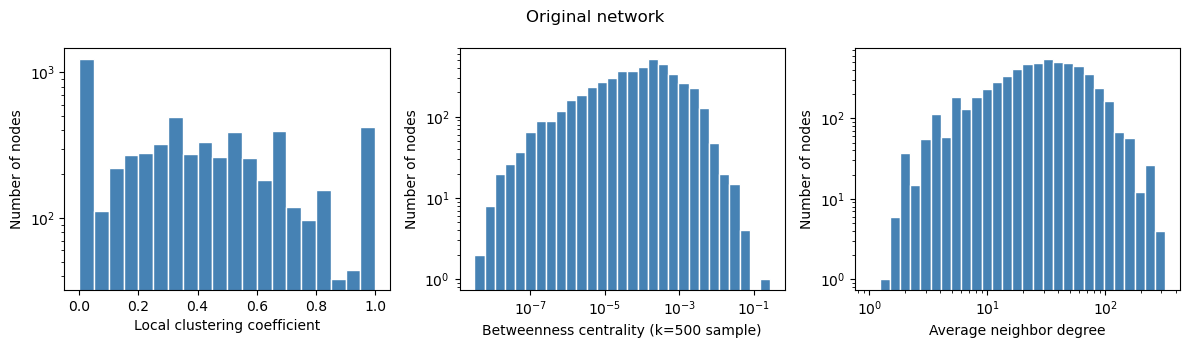

In [ ]:
# One figure with three panels; log axes only where values span orders of magnitude
def plot_stats(stats, title, filename):
    labels = {"clustering": "Local clustering coefficient",
              "betweenness": "Betweenness centrality (k=500 sample)",
              "neighbor degree": "Average neighbor degree"}
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, name in zip(axes, ["clustering", "betweenness", "neighbor degree"]):
        values = stats[name]
        if name != "clustering":                    # log x-axis: keep only positive values
            values = [v for v in values if v > 0]
            ax.set_xscale("log")
        counts, _, _ = ax.hist(values, bins=bins[name], color="steelblue", edgecolor="white")
        if counts.sum() > 0:
            ax.set_yscale("log")
        ax.set_xlabel(labels[name])
        ax.set_ylabel("Number of nodes")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

os.makedirs("figures", exist_ok=True)   # create the figures folder if it doesn't exist yet
plot_stats(stats_orig, "Original network", "figures/q5_original.pdf")

#### 5.b.2

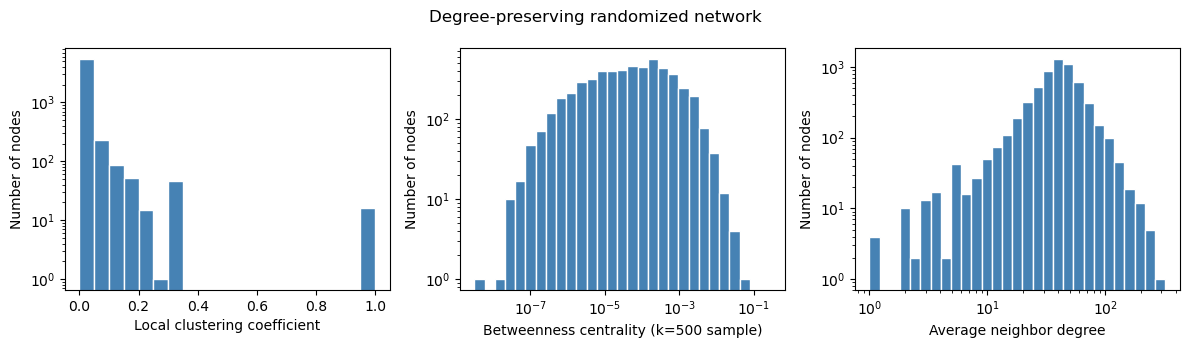

In [ ]:
plot_stats(stats_rand, "Degree-preserving randomized network", "figures/q5_randomized.pdf")

### 5.c

In [ ]:
# Summary numbers: real network vs degree-preserving null model
for name, g in [("original", G5), ("randomized", G5_rand)]:
    print(f"{name:11} avg clustering={nx.average_clustering(g):.3f}  "
          f"transitivity={nx.transitivity(g):.3f}  "
          f"degree assortativity={nx.degree_assortativity_coefficient(g):.3f}")

original    avg clustering=0.385  transitivity=0.301  degree assortativity=0.018
randomized  avg clustering=0.020  transitivity=0.019  degree assortativity=-0.027


Similarities. The null model preserves the degree of every node, so it has the same number of nodes and edges, the same average degree, and an identical degree sequence. The degree assortativity is also close to zero in both cases (0.018 in the original network, $-0.027$ in the randomized one): highly connected pages show no strong preference for linking to other highly connected pages, or to poorly connected ones.

Differences. The original network has an average clustering coefficient of 0.385 and a transitivity of 0.301, while the randomized version drops to 0.020 and 0.019. In the real network, if two pages are connected to the same page, there is a good chance that they are also connected to each other; once the edges are rewired at random, this behaviour largely disappears. We can infer that the high clustering reflects a genuine organizing principle of the network, likely groups of pages that link to each other because they share some property (homophily).

Why compare to a null model. A network measure on its own is hard to interpret: without a reference point, we cannot tell whether a clustering of 0.385 is high or low. A null model provides that baseline. It keeps some properties fixed (here, the degree sequence) and randomizes everything else. Comparing the real network to it separates the features that are simply a consequence of the degree distribution from those that require an additional explanation.